# Site description and context figures

This notebook gathers site-description plots for Hvalfjörður used in the introductory chapter.

- **Regional setting**: Show Iceland-wide map with a box highlighting Hvalfjörður.
- **Bathymetry**: Plot ROMS bathymetry overlaid on an OSM basemap and show fjord-scale zooms.
 - **CTD/mooring locations**: Mark HV CTD stations, moorings, and key infrastructure (piers, plant) on the map.
- **Local forcings**: Include wind roses and sea level anomaly time series from Grundartangi tidal gauge.



In [2]:
import subprocess
import os

import netCDF4
import numpy as np
import glob
import time
import matplotlib.pyplot as plt
import copy
import xarray as xr
from datetime import datetime, timedelta 
from roms_regrid import *
from celluloid import Camera 
import cartopy.crs as ccrs
import seawater as sw
import pandas as pd

/tmp/ipykernel_83677/2849830013.py:15: UserWarning: The seawater library is deprecated! Please use gsw instead.
  import seawater as sw


In [3]:
HAFRO_path='/home/x-uheede/R/HAFRO/Hafro_cruises.xls'

In [4]:
grid=xr.open_dataset('//home/x-uheede/R/MATLAB/setup_r2r_phys+bgc/1.Make_grid/Iceland3_grid_MAT.nc')
grid_pr=grid
h=grid['h'].values
mask_rho=grid['mask_rho'].values
pm=grid['pm'].values
pn=grid['pn'].values

In [5]:
h_regrid=roms_regrid(grid,grid_pr['h'])
mask_regrid=roms_regrid(grid,grid['mask_rho'])

In [6]:
import pandas as pd
import xarray as xr

# Read file
f='/home/x-uheede/R/HAFRO/Grundartangi_01012024-30122024.xlsx'
grundartangi = pd.read_excel(f, decimal=',')

# Parse time
time = grundartangi['Timabil'].str.strip()
time = pd.to_datetime(time, format="%H:%M\n%d.%m.%Y", dayfirst=True)

# Replace column
grundartangi['time'] = time

# Set time as index (optional but recommended)
grundartangi = grundartangi.set_index('time')

# Convert to xarray
ds = xr.Dataset.from_dataframe(grundartangi)
ds = ds.sortby("time")
ds

<xarray.Dataset> Size: 5MB
Dimensions:               (time: 52561)
Coordinates:
  * time                  (time) datetime64[ns] 420kB 2024-01-01 ... 2024-12-31
Data variables:
    Timabil               (time) object 420kB '00:00 01.01.2024 ' ... '00:00 ...
    Flodtafla (m)         (time) float64 420kB 2.56 2.46 2.36 ... 1.01 0.97 0.93
    Sj (m)                (time) float64 420kB 2.9 2.83 2.73 ... -3.73 -3.73
    Vindur (m/s)          (time) int64 420kB 1 1 1 1 2 1 1 3 ... 7 8 7 8 8 8 8 8
    Hvidda (m/s)          (time) int64 420kB 1 2 2 2 2 2 2 ... 9 9 9 10 10 10 9
    Vindatt               (time) int64 420kB 57 356 354 341 37 ... 59 58 58 59
    Loftværstingur (hpa)  (time) int64 420kB 998 998 998 998 ... 1013 1013 1013
    Lofthiti ©            (time) float64 420kB -4.0 -5.2 -4.7 ... -5.1 -4.5 -4.6
    Sjavarhiti ©          (time) float64 420kB 2.1 2.1 2.1 2.2 ... 1.5 1.6 1.7
    Selta (PSU)           (time) float64 420kB 20.54 20.52 20.53 ... 20.05 20.05
    Unnamed: 10           (time) object 420kB '  ' '  ' '  ' ... '  ' '  ' '  '

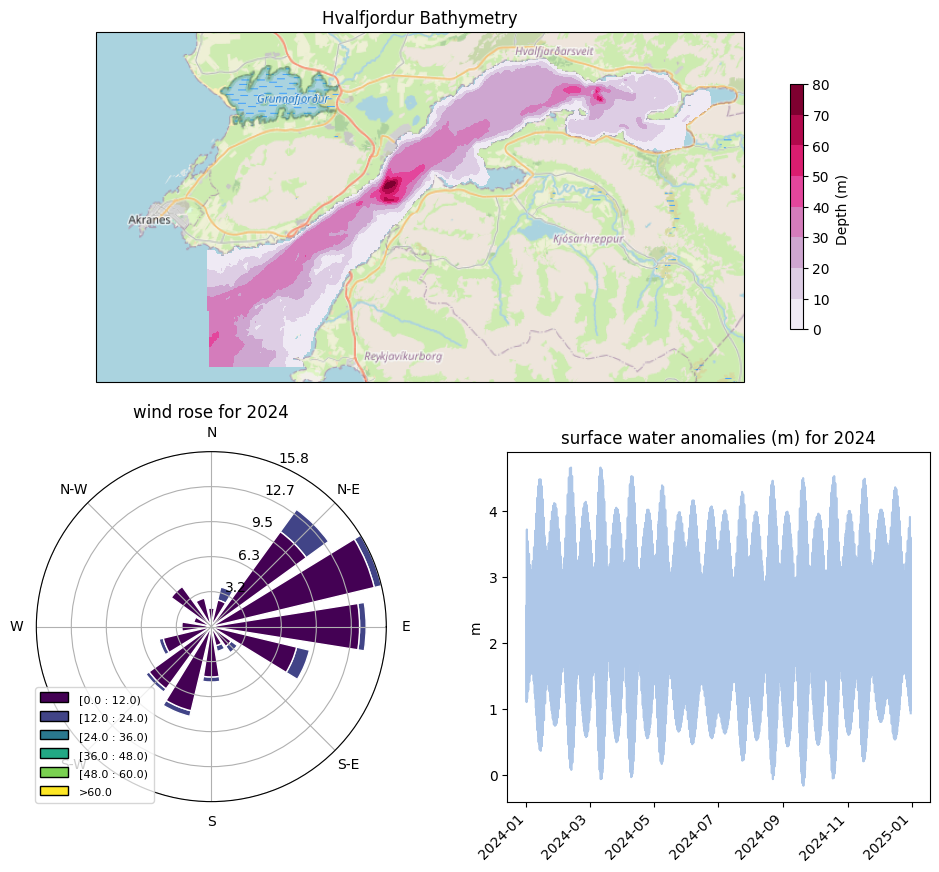

In [7]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt

# Define the basemap
request = cimgt.OSM()
extent = [-22.15, -21.3469394652069, 64.23, 64.41802068]

# Create figure with GridSpec: 2 rows, 2 columns
fig = plt.figure(figsize=(12, 10))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1])

# Top row: span both columns
ax1 = fig.add_subplot(gs[0, :], projection=request.crs)
ax1.set_extent(extent)
ax1.add_image(request, 10)
ax1.set_title("Hvalfjordur Bathymetry")

# Your contourf plot
cf1 = ax1.contourf(
    h_regrid.lon,
    h_regrid.lat,
    h_regrid.where(mask_regrid != 0),
    transform=ccrs.PlateCarree(),
    cmap="PuRd"
)

# Add colorbar
cbar = fig.colorbar(cf1, ax=ax1, orientation="vertical", shrink=0.7, pad=0.05)
cbar.set_label("Depth (m) ")

# Bottom row

from windrose import WindroseAxes
ax2 = WindroseAxes(fig, gs[1, 0])
fig.add_axes(ax2)  

ax2.bar(grundartangi['Vindatt'], grundartangi['Vindur (m/s)'], normed=True, opening=0.8, edgecolor='white')
ax2.set_legend()
ax2.set_title('wind rose for 2024')

palette = plt.get_cmap('tab20')
ax3 = fig.add_subplot(gs[1, 1])
ax3.set_title('surface water anomalies (m) for 2024')
ax3.plot(time,grundartangi['Flodtafla (m)'],color=palette(1))
ax3.set_ylabel('m')
#ax3.set_xlabel('time')
plt.setp(ax3.get_xticklabels(), rotation=45, ha="right")

#plt.tight_layout()
plt.show()


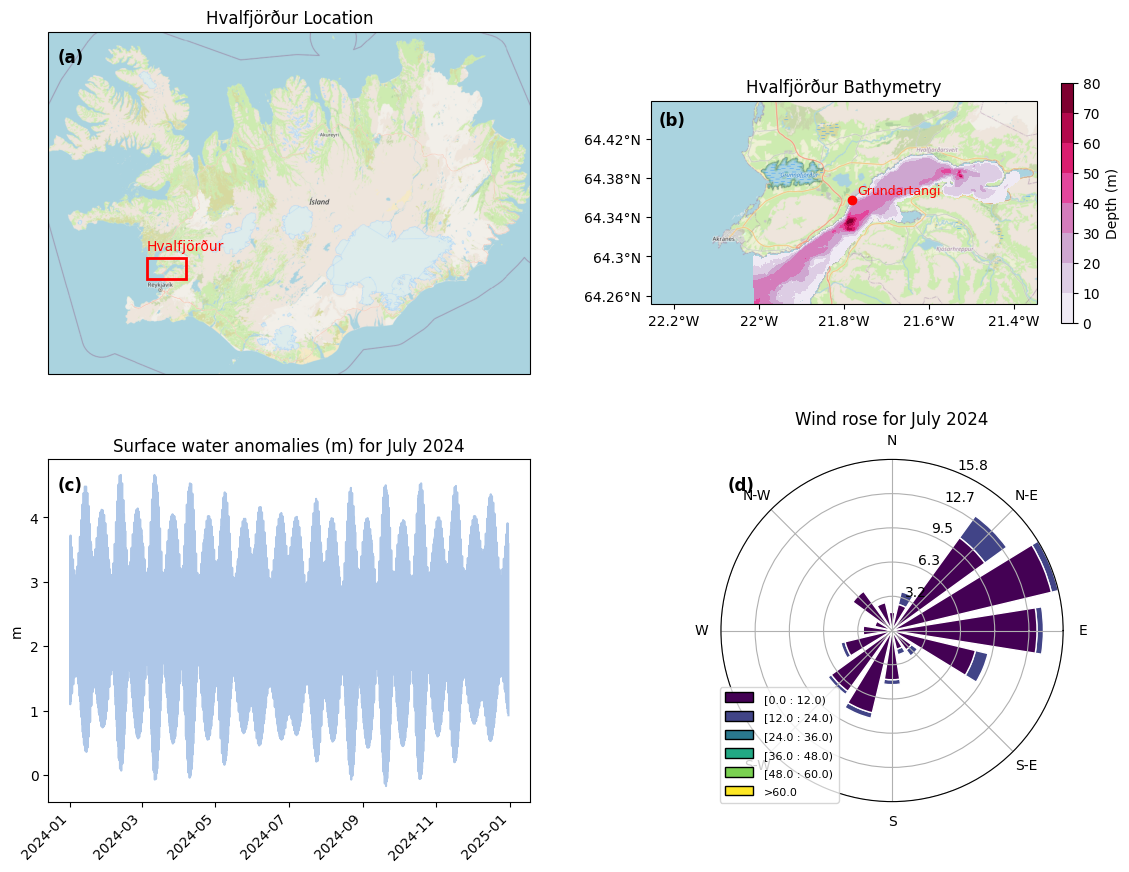

In [8]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt
import cartopy.mpl.ticker as cticker
from matplotlib.patches import Rectangle
from windrose import WindroseAxes

# Define the basemap
request = cimgt.OSM()

# Extents
extent_hval = [-22.2543190362897, -21.3469394652069, 64.25114671, 64.45802068]  # Hvalfjörður zoom
extent_iceland = [-24.5, -13.5, 63.3, 66.6]  # Iceland

# Create figure with GridSpec: 2 rows, 2 columns
fig = plt.figure(figsize=(14, 10))
gs = fig.add_gridspec(2, 2, width_ratios=[1, 1], height_ratios=[1, 1], wspace=0.25, hspace=0.25)

# --- Top left: Iceland map with box ---
ax_map = fig.add_subplot(gs[0, 0], projection=request.crs)
ax_map.set_extent(extent_iceland)
ax_map.add_image(request, 7)
ax_map.set_title("Hvalfjörður Location")

# Add rectangle showing Hvalfjörður extent
rect = Rectangle(
    (extent_hval[0], extent_hval[2]),  # bottom-left corner (lon, lat)
    extent_hval[1] - extent_hval[0],   # width (lon range)
    extent_hval[3] - extent_hval[2],   # height (lat range)
    linewidth=2, edgecolor='red', facecolor='none', transform=ccrs.PlateCarree()
)
ax_map.add_patch(rect)
ax_map.text(
    extent_hval[0], extent_hval[3] + 0.05,
    "Hvalfjörður",
    transform=ccrs.PlateCarree(),
    fontsize=10, color='red', ha='left', va='bottom'
)

# Panel label
ax_map.text(0.02, 0.95, "(a)", transform=ax_map.transAxes,
            fontsize=12, fontweight="bold", va="top", ha="left")

# --- Top right: Hvalfjörður Bathymetry ---
ax_bat = fig.add_subplot(gs[0, 1], projection=request.crs)
ax_bat.set_extent(extent_hval)
ax_bat.add_image(request, 10)
ax_bat.set_title("Hvalfjörður Bathymetry")

# Bathymetry contourf
cf = ax_bat.contourf(
    h_regrid.lon,
    h_regrid.lat,
    h_regrid.where(mask_regrid != 0),
    transform=ccrs.PlateCarree(),
    cmap="PuRd"
)

# Mark Grundartangi
ax_bat.plot(-21.7825, 64.3572, marker="o", color="red", markersize=6,
            transform=ccrs.PlateCarree())
ax_bat.text(-21.77, 64.36, "Grundartangi", color="red", fontsize=9,
            transform=ccrs.PlateCarree(), ha="left", va="bottom")

# Format ticks
ax_bat.set_xticks([-22.2, -22.0, -21.8, -21.6, -21.4], crs=ccrs.PlateCarree())
ax_bat.set_yticks([64.26, 64.30, 64.34, 64.38, 64.42], crs=ccrs.PlateCarree())
lon_formatter = cticker.LongitudeFormatter()
lat_formatter = cticker.LatitudeFormatter()
ax_bat.xaxis.set_major_formatter(lon_formatter)
ax_bat.yaxis.set_major_formatter(lat_formatter)

# Colorbar
cbar = fig.colorbar(cf, ax=ax_bat, orientation="vertical", shrink=0.7, pad=0.05)
cbar.set_label("Depth (m)")

# Panel label
ax_bat.text(0.02, 0.95, "(b)", transform=ax_bat.transAxes,
            fontsize=12, fontweight="bold", va="top", ha="left")

# --- Bottom left: Sea level anomalies ---
palette = plt.get_cmap('tab20')
ax_sea = fig.add_subplot(gs[1, 0])
ax_sea.set_title("Surface water anomalies (m) for July 2024")
ax_sea.plot(time, grundartangi['Flodtafla (m)'], color=palette(1))
ax_sea.set_ylabel("m")
plt.setp(ax_sea.get_xticklabels(), rotation=45, ha="right")

# Panel label
ax_sea.text(0.02, 0.95, "(c)", transform=ax_sea.transAxes,
            fontsize=12, fontweight="bold", va="top", ha="left")

# --- Bottom right: Wind rose ---
ax_wind = WindroseAxes(fig, gs[1, 1])
fig.add_axes(ax_wind)
ax_wind.bar(
    grundartangi['Vindatt'],
    grundartangi['Vindur (m/s)'],
    normed=True, opening=0.8, edgecolor="white"
)
ax_wind.set_legend()
ax_wind.set_title("Wind rose for July 2024")

# Panel label
ax_wind.text(0.02, 0.95, "(d)", transform=ax_wind.transAxes,
             fontsize=12, fontweight="bold", va="top", ha="left")

plt.show()


In [9]:
HAFRO_path='/home/x-uheede/R/HAFRO/Hafro_cruises.xls'

In [10]:
# Read in observed data
xls = pd.ExcelFile(HAFRO_path)

combo = pd.read_excel(xls, 'combo',decimal='.')

obs=xr.Dataset.from_dataframe(combo)

# reformat into xarray dataset, HV is our station number indicator
obs=obs.set_index(index=['HV','Depth','mon/day/yr'])
obs=obs.drop_duplicates('index')
obs=obs.unstack('index')
# renaming variables that have strange formatting in the excelsheet
obs=obs.rename(name_dict={'mon/day/yr':'time','Depth':'depth','Latitude(¬∞N)':'lat','Longitude(¬∞E)':'lon'})


In [11]:
# define location which calculations the average location of each station
def get_location(obs, hv_values):
    locations = []
    for hv in hv_values:
        lat = obs['lat'].sel(HV=hv).isel(depth=0).mean('time').squeeze().values
        lon = obs['lon'].sel(HV=hv).isel(depth=0).mean('time').squeeze().values 
        locations.append([lat, lon])
    return locations

# List of HV values
hv_values = range(1, 13)

# Get the locations
locations = get_location(obs, hv_values)

In [12]:
locations

[[array(64.27106), array(-22.03095)],
 [array(64.2865), array(-21.85915)],
 [array(64.29788889), array(-21.88442222)],
 [array(64.30706), array(-21.89406)],
 [array(64.33611818), array(-21.78663636)],
 [array(64.35979091), array(-21.68668182)],
 [array(64.36418889), array(-21.70105556)],
 [array(64.36879), array(-21.71566)],
 [array(64.38494), array(-21.63404)],
 [array(64.38192), array(-21.52629)],
 [array(64.3884), array(-21.52116667)],
 [array(64.3634), array(-21.44606)]]

In [13]:
Grundatangi=[-21.7825, 64.3572]


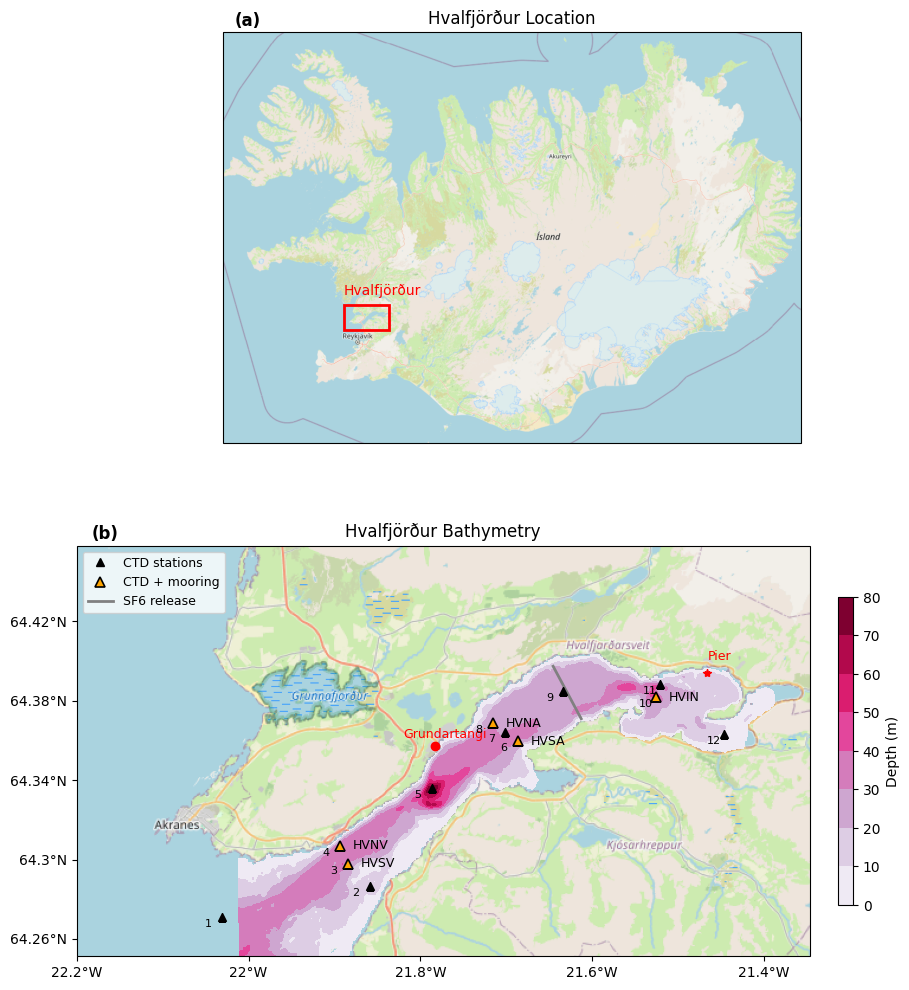

In [14]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt
import cartopy.mpl.ticker as cticker
from matplotlib.patches import Rectangle

# Define the basemap
request = cimgt.OSM()

# Extents
extent_hval = [-22.2, -21.3469394652069,
               64.25114671, 64.45802068]  # Hvalfjörður zoom
extent_iceland = [-24.5, -13.5, 63.3, 66.6]  # Iceland

# ---------------------------------------------------
# Create figure: 2 rows, 1 column
# ---------------------------------------------------
fig = plt.figure(figsize=(12, 12))
gs = fig.add_gridspec(
    2, 1,
    height_ratios=[1, 1],
    hspace=0.25
)

# ===================================================
# Panel (a) — Iceland map with Hvalfjörður box
# ===================================================
ax_map = fig.add_subplot(gs[0, 0], projection=request.crs)
ax_map.set_extent(extent_iceland)
ax_map.add_image(request, 7)
ax_map.set_title("Hvalfjörður Location")

# Rectangle showing Hvalfjörður
rect = Rectangle(
    (extent_hval[0], extent_hval[2]),
    extent_hval[1] - extent_hval[0],
    extent_hval[3] - extent_hval[2],
    linewidth=2,
    edgecolor="red",
    facecolor="none",
    transform=ccrs.PlateCarree()
)
ax_map.add_patch(rect)

ax_map.text(
    extent_hval[0], extent_hval[3] + 0.05,
    "Hvalfjörður",
    transform=ccrs.PlateCarree(),
    fontsize=10,
    color="red",
    ha="left",
    va="bottom"
)

# Panel label
ax_map.text(0.02, 1.05, "(a)", transform=ax_map.transAxes,
            fontsize=12, fontweight="bold",
            va="top", ha="left")

# ===================================================
# Panel (b) — Hvalfjörður bathymetry
# ===================================================
ax_bat = fig.add_subplot(gs[1, 0], projection=request.crs)
ax_bat.set_extent(extent_hval)
ax_bat.add_image(request, 10)
ax_bat.set_title("Hvalfjörður Bathymetry")

cf = ax_bat.contourf(
    h_regrid.lon,
    h_regrid.lat,
    h_regrid.where(mask_regrid != 0),
    transform=ccrs.PlateCarree(),
    cmap="PuRd"
)

# Mark Grundartangi
ax_bat.plot(
    -21.7825, 64.3572,
    marker="o", color="red", markersize=6,
    transform=ccrs.PlateCarree()
)
ax_bat.text(
    -21.82, 64.36,
    "Grundartangi",
    color="red",
    fontsize=9,
    transform=ccrs.PlateCarree(),
    ha="left",
    va="bottom"
)

# Mark Pier
ax_bat.plot(
    -21.465904, 64.394213,
    marker="*", color="red", markersize=6,
    transform=ccrs.PlateCarree()
)
ax_bat.text(
    -21.465904, 64.394213+0.005,
    "Pier",
    color="red",
    fontsize=9,
    transform=ccrs.PlateCarree(),
    ha="left",
    va="bottom"
)

ax_bat.text(
    0.02, 1.05, "(b)",
    transform=ax_bat.transAxes,
    fontsize=12,
    fontweight="bold",
    va="top",
    ha="left"
)

# -------------------------------------
# Line between two points
# -------------------------------------
points = [
    (64.3974, -21.6455 + 360),  # point A
    (64.3710, -21.6128 + 360),  # point B
]

# Unpack (lat, lon) → lon, lat for plotting
lats, lons = zip(*points)

ax_bat.plot(
    lons, lats,
    color="grey",
    linewidth=2,
    linestyle="-",
    transform=ccrs.PlateCarree(),
    label="SF6 release"
)



# -------------------------------------
# CTD stations
# -------------------------------------
ctd_mooring_ids = {3, 4, 6, 8, 10}

# Labels to the right of orange triangles
station_labels = {
    4: "HVNV",
    3: "HVSV",
    8: "HVNA",
    6: "HVSA",
    10: "HVIN"
}

first_ctd = True
first_combo = True

for i, (lat_arr, lon_arr) in enumerate(locations, start=1):
    lat = float(lat_arr)
    lon = float(lon_arr)

    if i in ctd_mooring_ids:
        marker_kwargs = dict(
            marker="^",
            markersize=7,
            markerfacecolor="orange",
            markeredgecolor="black",
            markeredgewidth=1.2,
            label="CTD + mooring" if first_combo else None
        )
        first_combo = False
    else:
        marker_kwargs = dict(
            marker="^",
            markersize=6,
            color="black",
            label="CTD stations" if first_ctd else None
        )
        first_ctd = False

    ax_bat.plot(
        lon, lat,
        transform=ccrs.PlateCarree(),
        **marker_kwargs
    )

    # station number
    ax_bat.text(
        lon - 0.02, lat - 0.001,
        f"{i}",
        fontsize=8,
        color="black",
        transform=ccrs.PlateCarree(),
        ha="left",
        va="top"
    )

    # -------------------------------------
    # Add HV labels to the RIGHT of triangles
    # -------------------------------------
    if i in station_labels:
        ax_bat.text(
            lon + 0.015,     # shift to right
            lat,
            station_labels[i],
            fontsize=9,
            color="black",
            transform=ccrs.PlateCarree(),
            ha="left",
            va="center"
        )
# Ticks and formatting
ax_bat.set_xticks([-22.2, -22.0, -21.8, -21.6, -21.4], crs=ccrs.PlateCarree())
ax_bat.set_yticks([64.26, 64.30, 64.34, 64.38, 64.42], crs=ccrs.PlateCarree())
ax_bat.xaxis.set_major_formatter(cticker.LongitudeFormatter())
ax_bat.yaxis.set_major_formatter(cticker.LatitudeFormatter())

# Colorbar
cbar = fig.colorbar(cf, ax=ax_bat, orientation="vertical",
                    shrink=0.75, pad=0.03)
cbar.set_label("Depth (m)")



from matplotlib.lines import Line2D

legend_handles = [
    Line2D(
        [0], [0],
        marker="^",
        linestyle="None",
        markerfacecolor="black",
        markeredgecolor="black",
        markersize=6,
        label="CTD stations"
    ),
    Line2D(
        [0], [0],
        marker="^",
        linestyle="None",
        markerfacecolor="orange",
        markeredgecolor="black",
        markeredgewidth=1.2,
        markersize=7,
        label="CTD + mooring"
    ),
    Line2D(
        [0], [0],
        color="grey",
        linewidth=2,
        linestyle="-",
        label="SF6 release"
    ),
]

ax_bat.legend(
    handles=legend_handles,
    loc="upper left",
    fontsize=9,
    frameon=True
)

plt.show()
